In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Estética general
plt.style.use("seaborn-v0_8")
sns.set_theme(style="whitegrid")

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["xtick.labelsize"] = 10
plt.rcParams["ytick.labelsize"] = 10

In [13]:
listings = pd.read_csv("listings.csv", low_memory=False)
calendar = pd.read_csv("calendar.csv", low_memory=False)
reviews  = pd.read_csv("reviews.csv", low_memory=False)

listings.shape, calendar.shape, reviews.shape

((23729, 106), (8661286, 7), (387099, 6))

In [ ]:
#priorizo variables de negocio: precio, ubicación, tipo de propiedad, reviews y ratings.
listings.info()

(listings.isnull().sum()
 .sort_values(ascending=False)
 .head(15))

listings.describe(include="all").T.head(15)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23729 entries, 0 to 23728
Columns: 106 entries, id to reviews_per_month
dtypes: float64(23), int64(21), object(62)
memory usage: 19.2+ MB


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,23729.0,NaN,NaN,NaN,26685552.304985,12633877.700716,11508.0,17656805.0,30008780.0,37362406.0,43286057.0
listing_url,23729,23729,https://www.airbnb.com/rooms/11508,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
scrape_id,23729.0,NaN,NaN,NaN,20200426042522.0,0.0,20200426042522.0,20200426042522.0,20200426042522.0,20200426042522.0,20200426042522.0
last_scraped,23729,2,2020-04-26,19435,NaN,NaN,NaN,NaN,NaN,NaN,NaN
name,23719,22918,Departamento en Recoleta,29,NaN,NaN,NaN,NaN,NaN,NaN,NaN
summary,22345,20951,.,56,NaN,NaN,NaN,NaN,NaN,NaN,NaN
space,16535,15536,Restaurantes + Bares + Discotecas + Arte + Gen...,19,NaN,NaN,NaN,NaN,NaN,NaN,NaN
description,22928,22139,Estamos cerca de las principales estaciones de...,20,NaN,NaN,NaN,NaN,NaN,NaN,NaN
experiences_offered,23729,1,none,23729,NaN,NaN,NaN,NaN,NaN,NaN,NaN
neighborhood_overview,16064,14240,El barrio es mágico. Cada vez más turistas eli...,22,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [25]:
# Limpieza de precio (remueve $ y comas)
listings["price"] = listings["price"].replace('[\$,]', '', regex=True).astype(float)

listings["price"].describe()

<>:2: SyntaxWarning: "\$" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\$"? A raw string is also an option.
<>:2: SyntaxWarning: "\$" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\$"? A raw string is also an option.
C:\Users\herna\AppData\Local\Temp\ipykernel_22800\251850842.py:2: SyntaxWarning: "\$" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\$"? A raw string is also an option.
  listings["price"] = listings["price"].replace('[\$,]', '', regex=True).astype(float)


count     23729.000000
mean       4014.875595
std       16075.326378
min           0.000000
25%        1394.000000
50%        2124.000000
75%        3319.000000
max      663732.000000
Name: price, dtype: float64

In [26]:
#Recomendacion de IA VS para evitar distorcion en graficos  
price_cap = listings["price"].quantile(0.99)
listings_f = listings[listings["price"] <= price_cap].copy()

price_cap, listings_f.shape

(np.float64(30442.040000000386), (23491, 106))

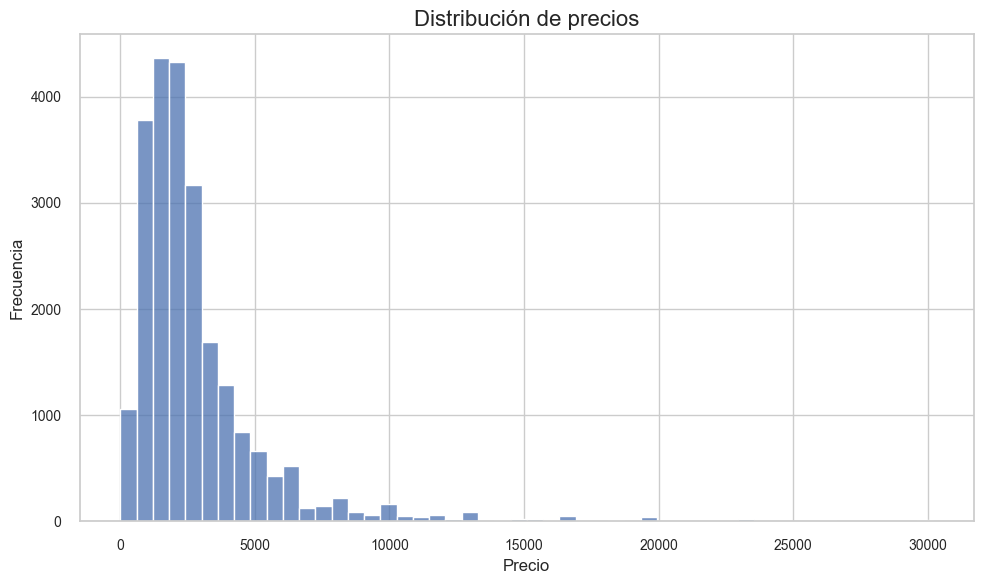

In [28]:
#Distribución de precios
sns.histplot(listings_f["price"].dropna(), bins=50)
plt.title("Distribución de precios")
plt.xlabel("Precio")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()

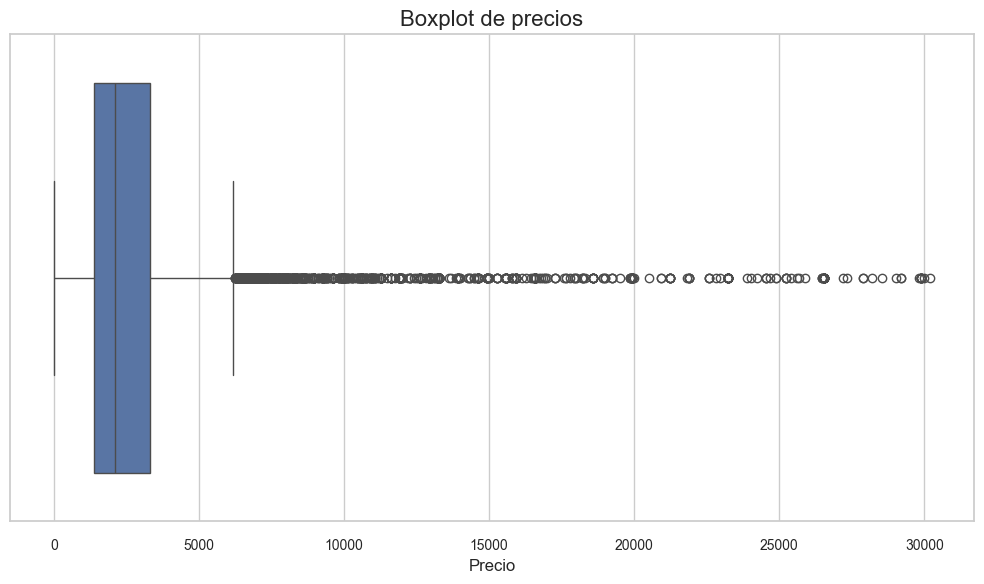

In [ ]:
#Boxplot de precios
sns.boxplot(x=listings_f["price"].dropna())
plt.title("Boxplot de precios")
plt.xlabel("Precio")
plt.tight_layout()
plt.show()
#Los precios están todos desparramados para la derecha.
#Hay unas pocas propiedades que inflan el promedio y te engañan si miras solo la media

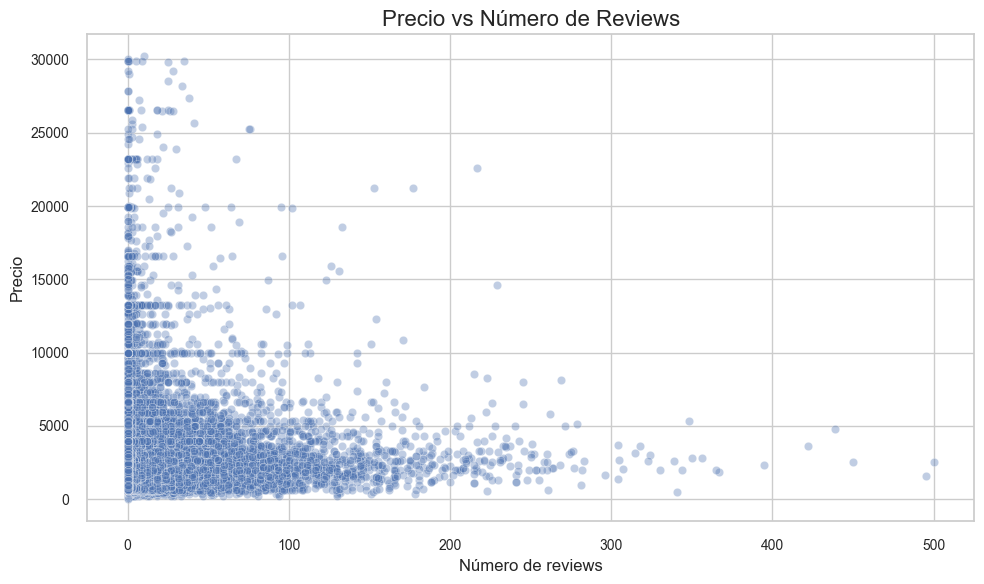

In [ ]:
subset = listings_f[["price", "number_of_reviews"]].dropna()

sns.scatterplot(data=subset, x="number_of_reviews", y="price", alpha=0.35)
plt.title("Precio vs Número de Reviews")
plt.xlabel("Número de reviews")
plt.ylabel("Precio")
plt.tight_layout()
plt.show()
#Lo interesante acá es que las propiedades que más reviews tienen no son las más caras. Más bien están en un rango de precio razonable.
#Esto hace pensar que el mercado responde mejor cuando el precio es moderado o razonable para el publico

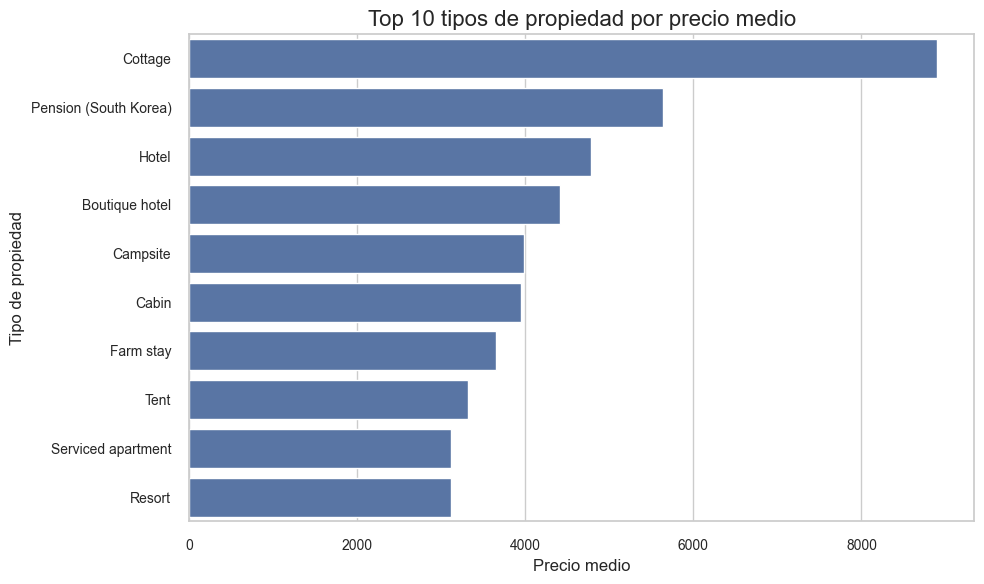

In [34]:
price_by_type = (
    listings_f
    .groupby("property_type")["price"]
    .median()
    .sort_values(ascending=False)
    .head(10)
)

sns.barplot(x=price_by_type.values, y=price_by_type.index)
plt.title("Top 10 tipos de propiedad por precio medio")
plt.xlabel("Precio medio")
plt.ylabel("Tipo de propiedad")
plt.tight_layout()
plt.show()

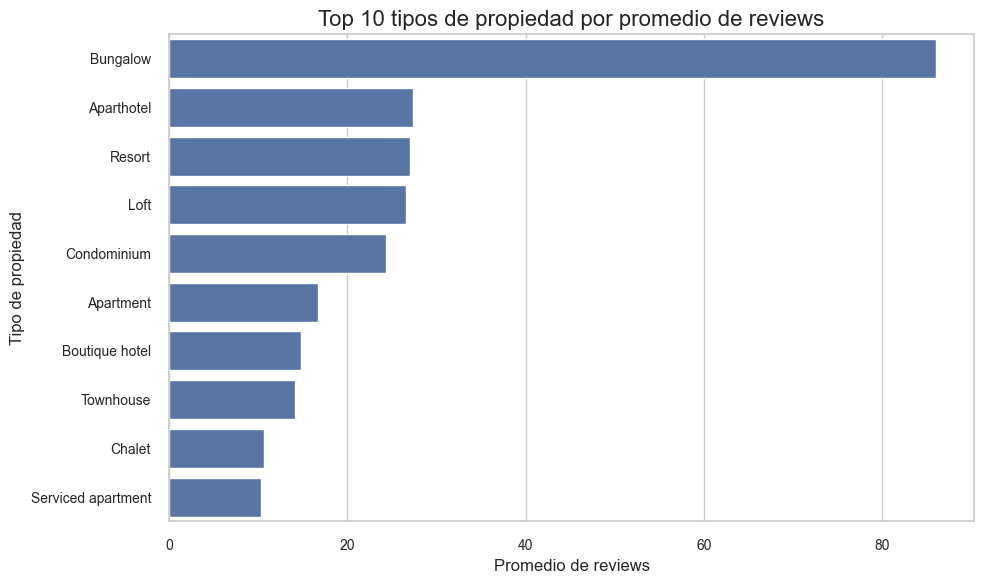

In [ ]:
reviews_by_type = (
    listings_f
    .groupby("property_type")["number_of_reviews"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

sns.barplot(x=reviews_by_type.values, y=reviews_by_type.index)
plt.title("Top 10 tipos de propiedad por promedio de reviews")
plt.xlabel("Promedio de reviews")
plt.ylabel("Tipo de propiedad")
plt.tight_layout()
plt.show()
#propiedades tipo Cottage o Boutique que claramente apuntan a algo más premium
#Lofts, Aparthoteles o Bungalows que no son los más caros pero generan más reviews, o sea más movimiento.
#como inversor, tengo que decidir si quiero apostar a algo mas premium o a más rotación.

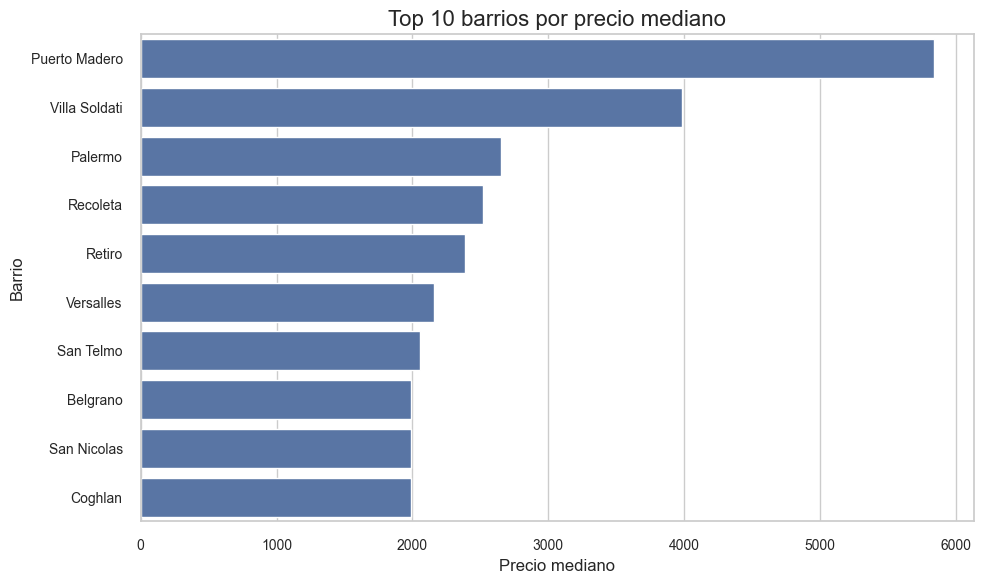

In [ ]:
price_by_neigh = (
    listings_f
    .groupby("neighbourhood_cleansed")["price"]
    .median()
    .sort_values(ascending=False)
    .head(10)
)

sns.barplot(x=price_by_neigh.values, y=price_by_neigh.index)
plt.title("Top 10 barrios por precio mediano")
plt.xlabel("Precio mediano")
plt.ylabel("Barrio")
plt.tight_layout()
plt.show()
#Puerto madero queda como el barrio top de precios medios
#Palermo y Recoleta aparecen como puntos interesantes, combinan buena ubicación con precios atractivos

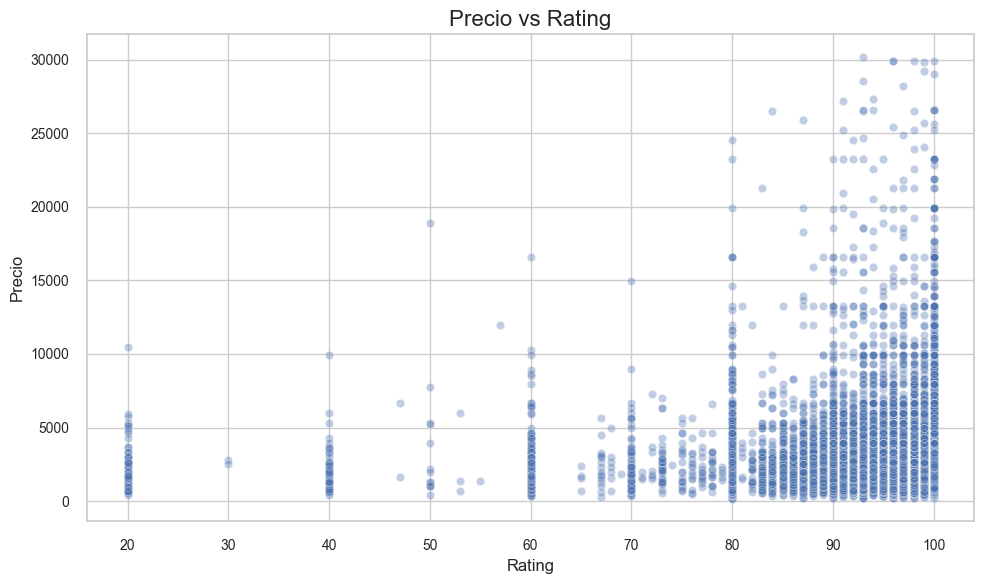

In [ ]:
rating_price = listings_f[["review_scores_rating", "price"]].dropna()

sns.scatterplot(data=rating_price, x="review_scores_rating", y="price", alpha=0.35)
plt.title("Precio vs Rating")
plt.xlabel("Rating")
plt.ylabel("Precio")
plt.tight_layout()
plt.show()
#Algo que me llamó la atención es que no por ser más caro tenés mejor rating
#Hay propiedades de precio medio con ratings altos, acá se ve que no es solo cobrar mas sino ofrecer un producto que genere conformidad al cliente


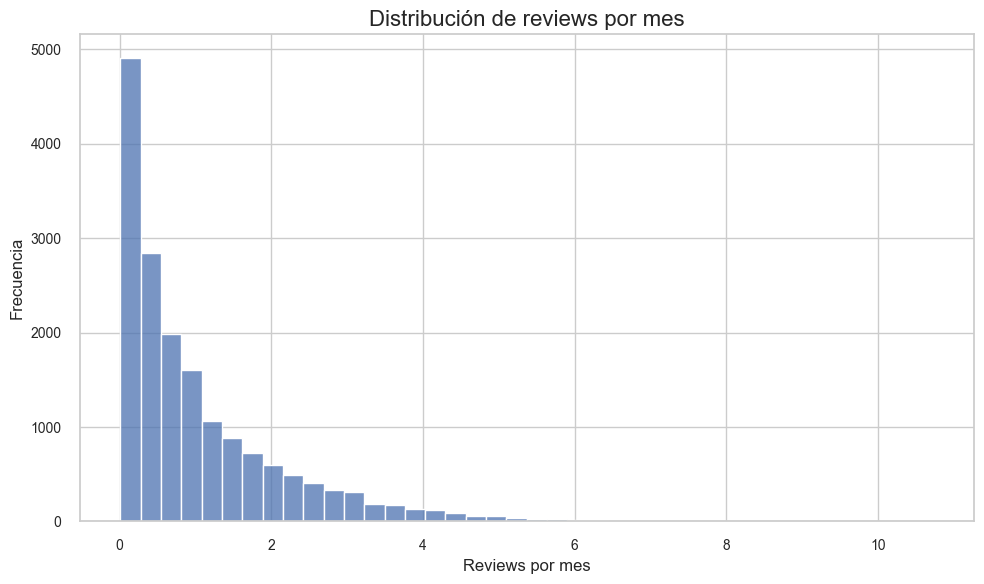

In [ ]:
sns.histplot(listings_f["reviews_per_month"].dropna(), bins=40)
plt.title("Distribución de reviews por mes")
plt.xlabel("Reviews por mes")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()
#Este gráfico muestra que la mayoría de las propiedades reciben pocas reviews por mes. Solo un grupo reducido logra alta rotación
#no todas las propiedades tienen el mismo nivel de demanda.

In [45]:
calendar["price"] = calendar["price"].replace('[\$,]', '', regex=True).astype(float)

availability = (
    calendar.groupby("listing_id")["available"]
    .apply(lambda x: (x == "t").mean())
    .reset_index()
)
availability.columns = ["id", "availability_rate"]

merged = listings_f.merge(availability, on="id", how="left")
merged[["price", "availability_rate"]].describe()

<>:1: SyntaxWarning: "\$" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\$"? A raw string is also an option.
<>:1: SyntaxWarning: "\$" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\$"? A raw string is also an option.
C:\Users\herna\AppData\Local\Temp\ipykernel_22800\1930913861.py:1: SyntaxWarning: "\$" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\$"? A raw string is also an option.
  calendar["price"] = calendar["price"].replace('[\$,]', '', regex=True).astype(float)


,price,availability_rate
count,23491.000000,23491.000000
mean,2877.232429,0.579606
std,2775.294160,0.375239
min,0.000000,0.000000
25%,1394.000000,0.243836
50%,2124.000000,0.493151
75%,3319.000000,0.994521
max,30203.000000,1.000000


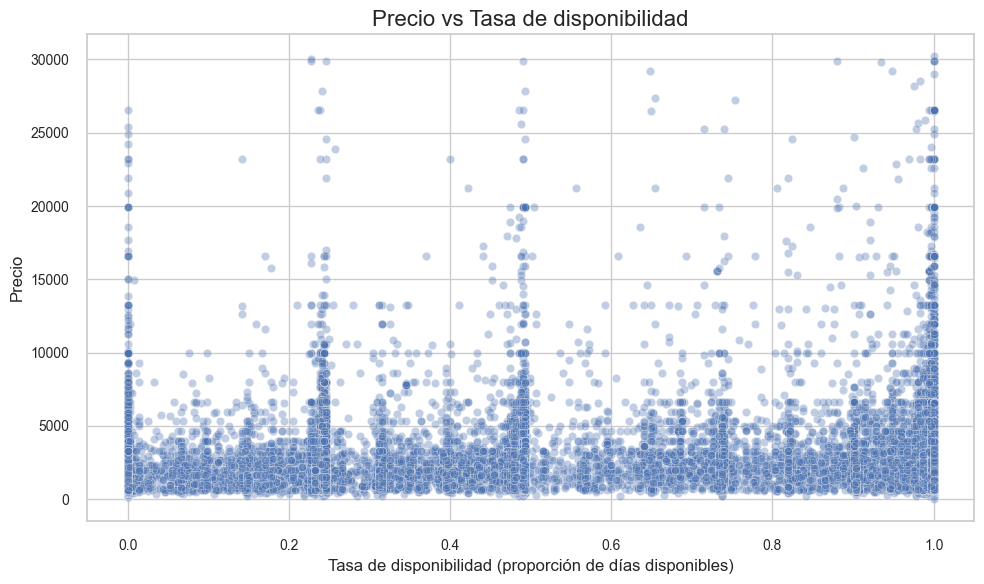

In [ ]:
sub = merged[["availability_rate", "price"]].dropna()

sns.scatterplot(data=sub, x="availability_rate", y="price", alpha=0.35)
plt.title("Precio vs Tasa de disponibilidad")
plt.xlabel("Tasa de disponibilidad (proporción de días disponibles)")
plt.ylabel("Precio")
plt.tight_layout()
plt.show()
#Este gráfico compara el precio con la tasa de disponibilidad. Una disponibilidad alta puede indicar baja ocupación.
#No se observa una relación clara entre el precio y la ocupacion lo que sugiere que el precio por sí solo no explica la demanda.

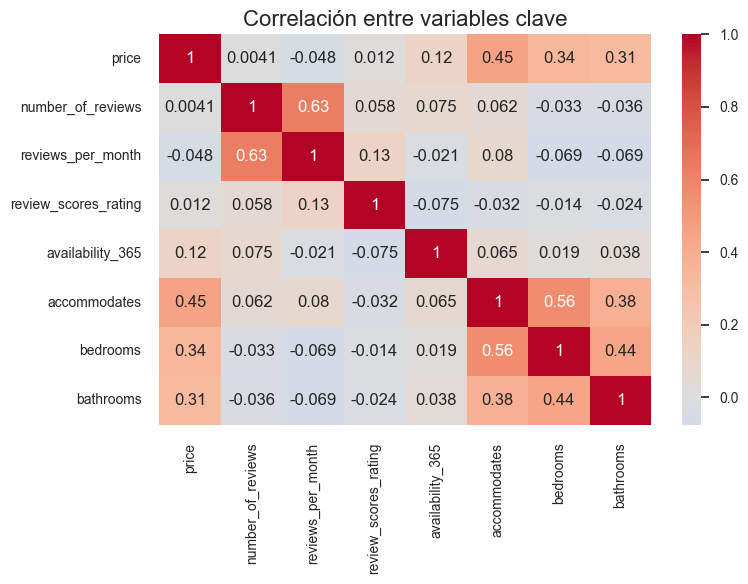

In [ ]:

cols_clave = [
    "price",
    "number_of_reviews",
    "reviews_per_month",
    "review_scores_rating",
    "availability_365",
    "accommodates",
    "bedrooms",
    "bathrooms"
]

corr_simple = listings_f[cols_clave].corr()

plt.figure(figsize=(8,6))
sns.heatmap(
    corr_simple,
    annot=True,      
    cmap="coolwarm",
    center=0
)

plt.title("Correlación entre variables clave")
plt.tight_layout()
plt.show()
#se observa que el precio se relaciona con el tamaño de la propiedad
#también se aprecia una relación lógica entre reviews por mes y disponibilidad anual, lo que sugiere que mayor actividad implica menor disponibilidad.